## Ensemble Model Pipeline Overview / 集成模型建模流程概览

This notebook implements the ensemble-model part of the water-quality prediction project. It follows the same general supervised-learning workflow as the other modeling notebooks, while focusing on tree-based ensemble methods.

The modeling process consists of the following steps:

1. **Load the cleaned dataset**
   Import the processed dataset created by the data-cleaning notebook.

2. **Define features and target**
   Use all valid predictors after removing leakage variables such as `Index`. The target is interpreted as `1 = unsafe` and `0 = safe`.

3. **Preprocessing**
   Impute missing values if needed and one-hot encode categorical variables. Feature scaling is not required for tree-based ensemble models.

4. **Decision Tree baseline**
   Use the tuned Decision Tree baseline from `04_model_2.ipynb` for comparison with ensemble models.

5. **Train ensemble models**
   Train Random Forest as a bagging ensemble and HistGradientBoosting as a boosting ensemble.

6. **Model evaluation and comparison**
   Compare models using Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC, with special attention to the unsafe class.

7. **Hyperparameter tuning and cross-validation**
   Use light randomized search and cross-validation to evaluate robustness without making runtime too heavy.

8. **Feature importance and interpretation**
   Analyze impurity-based and permutation-based feature importance, then connect top predictors to water-quality domain knowledge.

9. **Final conclusion**
   Summarize the preferred ensemble model, limitations, and interpretation boundaries.

---

具体流程如下：

1. **导入清洗后的数据**
   使用 data-cleaning notebook 输出的 processed dataset。

2. **定义特征与目标变量**
   删除 `Index` 等可能造成数据泄露的变量，并将 `Target` 解释为 `1 = unsafe`，`0 = safe`。

3. **数据预处理**
   对缺失值进行补充，对分类变量进行 one-hot encoding。

4. **正式 Decision Tree 基准模型**
   使用 `04_model_2.ipynb` 中调参后的 Decision Tree 作为 baseline，并与 ensemble models 进行比较。

5. **训练集成模型**
   使用 Random Forest 表示 bagging ensemble，使用 HistGradientBoosting 表示 boosting ensemble。

6. **模型评估与比较**
   使用 Accuracy、Precision、Recall、F1、ROC-AUC 和 PR-AUC 进行比较，尤其关注 unsafe 类的识别能力。

7. **调参和交叉验证**
   使用轻量 Randomized Search 和 cross-validation 检查模型稳定性。

8. **变量重要性与解释**
   使用 impurity-based importance 和 permutation importance 解释关键预测变量，并结合水质领域知识进行讨论。

9. **最终结论**
   总结推荐模型、局限性和解释边界。


### Research Questions / 研究问题

Q1. Can ensemble models such as Random Forest and Gradient Boosting predict the dataset target effectively?

Q2. Compared with a single Decision Tree baseline, do ensemble models improve predictive performance or robustness?

Q3. Which variables are most important for predicting unsafe water, and how can these variables be interpreted using water-quality domain knowledge?

Q4. Are the ensemble-model results stable under light hyperparameter tuning and cross-validation?

---

Q1. Random Forest 和 Gradient Boosting 这类集成模型能否有效预测数据集中的 `Target`？

Q2. 与单棵 Decision Tree baseline 相比，集成模型是否提升了预测表现或模型稳定性？

Q3. 哪些变量对 unsafe water 的预测最重要？这些变量如何结合水质领域知识进行解释？

Q4. 在轻量调参和交叉验证下，集成模型的结果是否稳定？


In [1]:
# Core libraries
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.20
POS_LABEL = 1  # Target=1 is interpreted as unsafe water.

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')


### Step 1: Load Data and Create the Shared Split

The notebook reads the cleaned dataset from `data/processed/water_quality_cleaned.csv`. If the cleaning strategy changes later, regenerate that file and rerun this notebook from the top.

All model notebooks should use the same stratified train-test split for fair comparison.


In [2]:
# Define project paths
PROJECT_ROOT = Path('..').resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'water_quality_cleaned.csv'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'
RESULT_DIR = PROJECT_ROOT / 'reports' / 'model_results'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Load the cleaned dataset
df = pd.read_csv(DATA_PATH)

# Basic validation checks
assert 'Target' in df.columns, 'The dataset must contain a Target column.'
assert 'Index' not in df.columns, 'Index should be removed before modelling to avoid leakage.'
assert df['Target'].isna().sum() == 0, 'Target must not contain missing values.'

print(f'Data path: {DATA_PATH}')
print(f'Shape: {df.shape}')
print('\nTarget distribution:')
print(df['Target'].value_counts())
print('\nTarget distribution (%):')
print((df['Target'].value_counts(normalize=True) * 100).round(2))
print('\nMissing values after cleaning:')
print(df.isna().sum().sum())

df.head()


Data path: E:\Python and Advanced Data Science\Project\data\processed\water_quality_cleaned.csv
Shape: (734756, 23)

Target distribution:
Target
0    565630
1    169126
Name: count, dtype: int64

Target distribution (%):
Target
0    76.98
1    23.02
Name: proportion, dtype: float64

Missing values after cleaning:
0


,pH,Iron,Nitrate,Chloride,Lead,Zinc,Color,Turbidity,Fluoride,Copper,Odor,Sulfate,Conductivity,Chlorine,Manganese,Total Dissolved Solids,Source,Water Temperature,Air Temperature,Month,Day,Time of Day,Target
0,6.917863,8.050000e-05,3.734167,227.029851,7.850000e-94,1.245317,Faint Yellow,0.019007,0.622874,0.437835,1.686049,144.010981,432.844908,3.292038,8.020000e-07,284.641984,Lake,15.348981,71.220586,11.0,26.0,16.0,0
1,5.443762,2.010586e-02,3.816994,230.995630,5.290000e-76,0.528280,Light Yellow,0.319956,0.423423,0.431588,3.414619,275.702107,990.201209,3.560224,7.007989e-02,570.054094,River,11.643467,44.891330,1.0,31.0,8.0,0
2,8.091909,2.167128e-03,9.925788,186.540872,4.170000e-132,3.807511,Light Yellow,0.004867,0.222912,0.616574,0.795310,175.275175,385.025855,3.177849,3.296139e-03,168.075545,Spring,15.249416,69.336671,6.0,29.0,7.0,0
3,7.258203,6.110000e-09,9.261676,182.242341,4.400000e-224,0.416478,Colorless,0.047803,1.016196,0.298093,3.144199,114.551427,160.062557,2.325094,6.020000e-16,214.553104,River,15.891905,61.139140,4.0,11.0,4.0,0
4,7.100650,3.019038e-03,3.620641,157.043934,6.460000e-148,0.112994,Colorless,0.050613,0.842107,0.391602,2.713379,167.417837,583.295321,2.284971,8.840000e-07,113.909077,River,11.899376,14.010268,4.0,7.0,12.0,0


In [3]:
# Separate features and target
TARGET_COL = 'Target'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

# Detect column types automatically
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = [col for col in X.columns if col not in categorical_features]

print(f'Numerical features ({len(numeric_features)}):')
print(numeric_features)
print(f'\nCategorical features ({len(categorical_features)}):')
print(categorical_features)

# Stratified train-test split for fair model comparison
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')
print('\nTrain target distribution:')
print(y_train.value_counts(normalize=True).round(3))
print('\nTest target distribution:')
print(y_test.value_counts(normalize=True).round(3))

# Save split indices for reproducibility across notebooks
split_index = pd.concat(
    [
        pd.DataFrame({'row_index': X_train.index, 'split': 'train'}),
        pd.DataFrame({'row_index': X_test.index, 'split': 'test'}),
    ],
    ignore_index=True,
)
split_path = RESULT_DIR / 'train_test_split_indices.csv'
split_index.to_csv(split_path, index=False)
print(f'\nSaved split indices to: {split_path}')


Numerical features (20):
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day']

Categorical features (2):
['Color', 'Source']
Train shape: (587804, 22)
Test shape: (146952, 22)

Train target distribution:
Target
0    0.77
1    0.23
Name: proportion, dtype: float64

Test target distribution:
Target
0    0.77
1    0.23
Name: proportion, dtype: float64

Saved split indices to: E:\Python and Advanced Data Science\Project\reports\model_results\train_test_split_indices.csv


### Step 2: Preprocessing and Evaluation Helpers

Tree-based ensemble models do not require feature scaling, but they do require numeric input. The preprocessing pipeline imputes missing values and one-hot encodes categorical variables.

The unsafe class (`Target = 1`) is the most important class from a public-health perspective. A false negative means unsafe water is predicted as safe, so recall for the unsafe class is emphasized.


In [4]:
# OneHotEncoder changed the sparse argument name in newer scikit-learn versions.
# This helper keeps the notebook compatible with different local environments.
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_one_hot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print('Preprocessing pipeline is ready.')


Preprocessing pipeline is ready.


In [5]:
# Evaluation helper for binary classifiers
def evaluate_classifier(model, X_eval, y_eval, model_name):
    # Predict classes and scores.
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_eval)
    else:
        y_score = y_pred

    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision_unsafe': precision_score(y_eval, y_pred, pos_label=POS_LABEL, zero_division=0),
        'recall_unsafe': recall_score(y_eval, y_pred, pos_label=POS_LABEL, zero_division=0),
        'f1_unsafe': f1_score(y_eval, y_pred, pos_label=POS_LABEL, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, y_score),
        'pr_auc': average_precision_score(y_eval, y_score),
    }
    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
    return metrics, cm, y_pred, y_score


def show_classification_report(model, X_eval, y_eval, model_name):
    # Print a labelled classification report.
    y_pred = model.predict(X_eval)
    print(f'Classification report: {model_name}')
    print(classification_report(y_eval, y_pred, target_names=['Safe (0)', 'Unsafe (1)'], zero_division=0))


def plot_confusion_matrix(cm, model_name, filename):
    # Plot and save a confusion matrix.
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (0)', 'Unsafe (1)'])
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(model_name)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()


### Step 3: Decision Tree Baseline from `04_model_2.ipynb`

The baseline now follows the teammate's Decision Tree notebook:

- `Color` is encoded using the same ordinal order;
- `Source` is one-hot encoded;
- the tuned Decision Tree parameters from `04_model_2.ipynb` are used: `max_depth=20`, `min_samples_leaf=10`, and `min_samples_split=2`.

For a fair comparison with the ensemble models, this baseline uses the same train/test row split already created in this notebook.


Saved Decision Tree baseline metrics to: E:\Python and Advanced Data Science\Project\reports\model_results\decision_tree_04_tuned_baseline_metrics.csv


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
0,Decision Tree (04 tuned baseline),0.8591,0.6485,0.8472,0.7346,0.913,0.6462


Classification report: Decision Tree (04 tuned baseline)
              precision    recall  f1-score   support

    Safe (0)       0.95      0.86      0.90    113127
  Unsafe (1)       0.65      0.85      0.73     33825

    accuracy                           0.86    146952
   macro avg       0.80      0.85      0.82    146952
weighted avg       0.88      0.86      0.87    146952



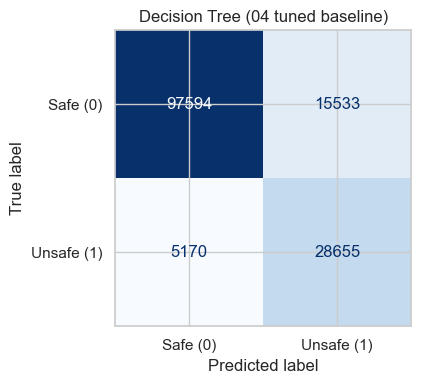

In [6]:
# Recreate the tuned Decision Tree baseline from 04_model_2.ipynb.

RUN_DECISION_TREE_BASELINE = True

decision_tree_baseline_metrics = None
decision_tree_baseline_cm = None
decision_tree_baseline_model = None

if RUN_DECISION_TREE_BASELINE:
    # Follow the teammate's encoding logic from 04_model_2.ipynb.
    X_dt_baseline = X.copy()

    if 'Color' in X_dt_baseline.columns:
        color_order = ['Colorless', 'Near Colorless', 'Faint Yellow', 'Light Yellow', 'Yellow']
        color_mapping = {category: index for index, category in enumerate(color_order)}
        X_dt_baseline['Color'] = X_dt_baseline['Color'].map(color_mapping)

        if X_dt_baseline['Color'].isna().any():
            unknown_colors = X.loc[X_dt_baseline['Color'].isna(), 'Color'].dropna().unique()
            raise ValueError(f'Unexpected Color values found: {unknown_colors}')

    if 'Source' in X_dt_baseline.columns:
        X_dt_baseline = pd.get_dummies(X_dt_baseline, columns=['Source'], drop_first=False)

    # Use the exact same row split as the ensemble models for a fair comparison.
    X_train_dt_baseline = X_dt_baseline.loc[X_train.index].copy()
    X_test_dt_baseline = X_dt_baseline.loc[X_test.index].copy()
    y_train_dt_baseline = y_train.copy()
    y_test_dt_baseline = y_test.copy()

    # Align columns in case future cleaned data has a missing source category in one split.
    X_test_dt_baseline = X_test_dt_baseline.reindex(columns=X_train_dt_baseline.columns, fill_value=0)

    decision_tree_baseline_model = DecisionTreeClassifier(
        max_depth=20,
        min_samples_leaf=10,
        min_samples_split=2,
        random_state=RANDOM_STATE,
    )

    decision_tree_baseline_model.fit(X_train_dt_baseline, y_train_dt_baseline)
    decision_tree_baseline_metrics, decision_tree_baseline_cm, _, _ = evaluate_classifier(
        decision_tree_baseline_model,
        X_test_dt_baseline,
        y_test_dt_baseline,
        'Decision Tree (04 tuned baseline)',
    )

    decision_tree_baseline_results_path = RESULT_DIR / 'decision_tree_04_tuned_baseline_metrics.csv'
    pd.DataFrame([decision_tree_baseline_metrics]).to_csv(decision_tree_baseline_results_path, index=False)

    print(f'Saved Decision Tree baseline metrics to: {decision_tree_baseline_results_path}')
    display(pd.DataFrame([decision_tree_baseline_metrics]).round(4))
    show_classification_report(
        decision_tree_baseline_model,
        X_test_dt_baseline,
        y_test_dt_baseline,
        'Decision Tree (04 tuned baseline)',
    )
    plot_confusion_matrix(
        decision_tree_baseline_cm,
        'Decision Tree (04 tuned baseline)',
        'decision_tree_04_tuned_baseline_confusion_matrix.png',
    )
else:
    print('Decision Tree baseline skipped.')


### Step 4: Train Ensemble Models

Random Forest represents bagging. HistGradientBoosting represents boosting. Both are ensemble models and satisfy the assignment's ensemble-model requirement.


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
0,Random Forest,0.8669,0.6357,0.9881,0.7736,0.9204,0.6642


Classification report: Random Forest
              precision    recall  f1-score   support

    Safe (0)       1.00      0.83      0.91    113127
  Unsafe (1)       0.64      0.99      0.77     33825

    accuracy                           0.87    146952
   macro avg       0.82      0.91      0.84    146952
weighted avg       0.91      0.87      0.88    146952



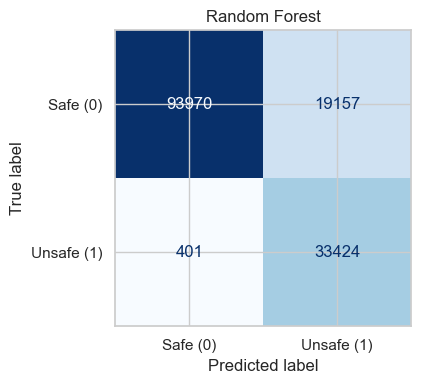

In [7]:
# Random Forest model: bagging ensemble
rf_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        (
            'model',
            RandomForestClassifier(
                n_estimators=150,
                max_depth=18,
                min_samples_leaf=5,
                max_features='sqrt',
                class_weight='balanced_subsample',
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

rf_model.fit(X_train, y_train)
rf_metrics, rf_cm, rf_pred, rf_score = evaluate_classifier(
    rf_model,
    X_test,
    y_test,
    'Random Forest',
)

display(pd.DataFrame([rf_metrics]).round(4))
show_classification_report(rf_model, X_test, y_test, 'Random Forest')
plot_confusion_matrix(rf_cm, 'Random Forest', 'ensemble_random_forest_confusion_matrix.png')

  File "D:\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
0,HistGradientBoosting,0.8711,0.6467,0.9702,0.7761,0.9176,0.6478


Classification report: HistGradientBoosting
              precision    recall  f1-score   support

    Safe (0)       0.99      0.84      0.91    113127
  Unsafe (1)       0.65      0.97      0.78     33825

    accuracy                           0.87    146952
   macro avg       0.82      0.91      0.84    146952
weighted avg       0.91      0.87      0.88    146952



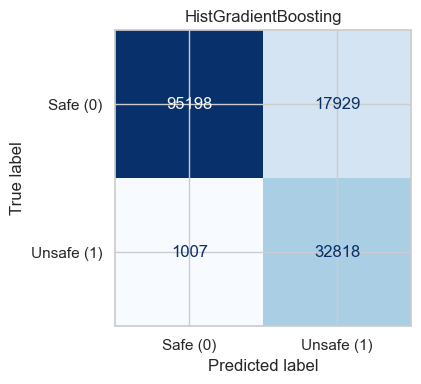

In [8]:
# HistGradientBoosting model: boosting ensemble
# It is used instead of classic GradientBoostingClassifier because it scales better to this dataset size.
hgb_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        (
            'model',
            HistGradientBoostingClassifier(
                learning_rate=0.08,
                max_iter=200,
                max_leaf_nodes=31,
                min_samples_leaf=30,
                l2_regularization=0.1,
                early_stopping=True,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

hgb_model.fit(X_train, y_train)
hgb_metrics, hgb_cm, hgb_pred, hgb_score = evaluate_classifier(
    hgb_model,
    X_test,
    y_test,
    'HistGradientBoosting',
)

display(pd.DataFrame([hgb_metrics]).round(4))
show_classification_report(hgb_model, X_test, y_test, 'HistGradientBoosting')
plot_confusion_matrix(hgb_cm, 'HistGradientBoosting', 'ensemble_hist_gradient_boosting_confusion_matrix.png')


### Step 5: Model Comparison

The official ensemble comparison table contains only Random Forest and HistGradientBoosting. The temporary Decision Tree table is displayed separately and can be replaced by the teammate's official result later.


In [9]:
# Official ensemble results from this notebook
ensemble_results = pd.DataFrame([rf_metrics, hgb_metrics])
metric_cols = ['accuracy', 'precision_unsafe', 'recall_unsafe', 'f1_unsafe', 'roc_auc', 'pr_auc']
ensemble_results = ensemble_results[['model'] + metric_cols].sort_values('f1_unsafe', ascending=False)

ensemble_results_path = RESULT_DIR / 'ensemble_model_results.csv'
ensemble_results.to_csv(ensemble_results_path, index=False)

# Display table including the teammate's tuned Decision Tree baseline from 04_model_2.ipynb.
comparison_rows = []
if decision_tree_baseline_metrics is not None:
    comparison_rows.append(decision_tree_baseline_metrics)
comparison_rows.extend([rf_metrics, hgb_metrics])

comparison_with_decision_tree_baseline = pd.DataFrame(comparison_rows)[['model'] + metric_cols]
comparison_with_decision_tree_baseline = comparison_with_decision_tree_baseline.sort_values(
    'f1_unsafe', ascending=False
)

comparison_with_baseline_path = RESULT_DIR / 'ensemble_comparison_with_decision_tree_baseline.csv'
comparison_with_decision_tree_baseline.to_csv(comparison_with_baseline_path, index=False)

print(f'Saved ensemble comparison with Decision Tree baseline to: {comparison_with_baseline_path}')
display(comparison_with_decision_tree_baseline.round(4))


Saved ensemble comparison with Decision Tree baseline to: E:\Python and Advanced Data Science\Project\reports\model_results\ensemble_comparison_with_decision_tree_baseline.csv


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
2,HistGradientBoosting,0.8711,0.6467,0.9702,0.7761,0.9176,0.6478
1,Random Forest,0.8669,0.6357,0.9881,0.7736,0.9204,0.6642
0,Decision Tree (04 tuned baseline),0.8591,0.6485,0.8472,0.7346,0.9130,0.6462


### Step 6: Light Hyperparameter Tuning

The assignment asks for tuning. To keep runtime manageable, tuning is performed on a stratified sample of the training data. The selected parameters are then used to fit tuned models on the full training set.

If runtime is too long, reduce `TUNING_SAMPLE_SIZE` or set `RUN_TUNING = False`.

> 调参这里用训练集的一部分做随机搜索，是为了节省时间。最终选出的 tuned model 会重新在完整训练集上训练，然后在 test set 上评估。


In [10]:
# Tuning controls
RUN_TUNING = True
TUNING_SAMPLE_SIZE = 100_000
N_ITER_SEARCH = 8
CV_FOLDS = 3


def make_tuning_sample(X_source, y_source, sample_size, random_state):
    # Create a stratified sample for hyperparameter tuning.
    if sample_size >= len(X_source):
        return X_source, y_source
    X_sample, _, y_sample, _ = train_test_split(
        X_source,
        y_source,
        train_size=sample_size,
        stratify=y_source,
        random_state=random_state,
    )
    return X_sample, y_sample


X_tune, y_tune = make_tuning_sample(X_train, y_train, TUNING_SAMPLE_SIZE, RANDOM_STATE)
print(f'Tuning sample shape: {X_tune.shape}')
print(y_tune.value_counts(normalize=True).round(3))


Tuning sample shape: (100000, 22)
Target
0    0.77
1    0.23
Name: proportion, dtype: float64


In [11]:
tuned_results = []
tuned_models = {}

if RUN_TUNING:
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    rf_search_model = Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('model', RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE)),
        ]
    )

    rf_param_distributions = {
        'model__n_estimators': [100, 150, 200],
        'model__max_depth': [12, 18, 24, None],
        'model__min_samples_leaf': [1, 3, 5, 10],
        'model__max_features': ['sqrt', 0.5, None],
        'model__class_weight': ['balanced_subsample', 'balanced', None],
    }

    rf_search = RandomizedSearchCV(
        estimator=rf_search_model,
        param_distributions=rf_param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )

    rf_search.fit(X_tune, y_tune)
    print('Best Random Forest parameters:')
    print(rf_search.best_params_)
    print(f'Best CV F1: {rf_search.best_score_:.4f}')

    tuned_rf_model = rf_search.best_estimator_
    tuned_rf_model.fit(X_train, y_train)
    tuned_rf_metrics, tuned_rf_cm, _, _ = evaluate_classifier(
        tuned_rf_model, X_test, y_test, 'Random Forest (tuned)'
    )
    tuned_results.append(tuned_rf_metrics)
    tuned_models['Random Forest (tuned)'] = tuned_rf_model
else:
    print('Tuning skipped for Random Forest.')


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 10, 'model__max_features': 0.5, 'model__max_depth': None, 'model__class_weight': 'balanced'}
Best CV F1: 0.7784


In [12]:
if RUN_TUNING:
    hgb_search_model = Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('model', HistGradientBoostingClassifier(early_stopping=True, random_state=RANDOM_STATE)),
        ]
    )

    hgb_param_distributions = {
        'model__learning_rate': [0.03, 0.05, 0.08, 0.10],
        'model__max_iter': [150, 200, 300],
        'model__max_leaf_nodes': [15, 31, 63],
        'model__min_samples_leaf': [20, 30, 50, 100],
        'model__l2_regularization': [0.0, 0.01, 0.1, 1.0],
    }

    hgb_search = RandomizedSearchCV(
        estimator=hgb_search_model,
        param_distributions=hgb_param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )

    hgb_search.fit(X_tune, y_tune)
    print('Best HistGradientBoosting parameters:')
    print(hgb_search.best_params_)
    print(f'Best CV F1: {hgb_search.best_score_:.4f}')

    tuned_hgb_model = hgb_search.best_estimator_
    tuned_hgb_model.fit(X_train, y_train)
    tuned_hgb_metrics, tuned_hgb_cm, _, _ = evaluate_classifier(
        tuned_hgb_model, X_test, y_test, 'HistGradientBoosting (tuned)'
    )
    tuned_results.append(tuned_hgb_metrics)
    tuned_models['HistGradientBoosting (tuned)'] = tuned_hgb_model
else:
    print('Tuning skipped for HistGradientBoosting.')


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best HistGradientBoosting parameters:
{'model__min_samples_leaf': 30, 'model__max_leaf_nodes': 31, 'model__max_iter': 300, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.0}
Best CV F1: 0.7746


In [13]:
# Compare untuned and tuned ensemble models
all_ensemble_metrics = [rf_metrics, hgb_metrics] + tuned_results
all_ensemble_results = pd.DataFrame(all_ensemble_metrics)[['model'] + metric_cols]
all_ensemble_results = all_ensemble_results.sort_values('f1_unsafe', ascending=False)

all_results_path = RESULT_DIR / 'ensemble_model_results_with_tuning.csv'
all_ensemble_results.to_csv(all_results_path, index=False)

print(f'Saved tuned comparison to: {all_results_path}')
display(all_ensemble_results.round(4))


Saved tuned comparison to: E:\Python and Advanced Data Science\Project\reports\model_results\ensemble_model_results_with_tuning.csv


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
2,Random Forest (tuned),0.8723,0.6468,0.9806,0.7794,0.9226,0.6826
3,HistGradientBoosting (tuned),0.8712,0.6467,0.9708,0.7763,0.9181,0.6496
1,HistGradientBoosting,0.8711,0.6467,0.9702,0.7761,0.9176,0.6478
0,Random Forest,0.8669,0.6357,0.9881,0.7736,0.9204,0.6642


### Step 7: Cross-Validation

Following the structure of the Logistic Regression notebook, this section adds a separate cross-validation check for the ensemble models. Since ensemble models are computationally heavier, cross-validation is performed on a stratified sample of the training data.

The goal is not to replace the held-out test-set evaluation, but to check whether the model performance is reasonably stable across folds.


In [14]:
# Cross-validation for ensemble model robustness
# A stratified sample keeps runtime manageable while preserving the class ratio.
RUN_CROSS_VALIDATION = True
CV_SAMPLE_SIZE = 50_000

CV_METRICS = {
    'accuracy': 'accuracy',
    'precision_unsafe': 'precision',
    'recall_unsafe': 'recall',
    'f1_unsafe': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}


def make_cross_validation_sample(X_source, y_source, sample_size, random_state):
    # Create a stratified sample for cross-validation.
    if sample_size >= len(X_source):
        return X_source, y_source
    X_sample, _, y_sample, _ = train_test_split(
        X_source,
        y_source,
        train_size=sample_size,
        stratify=y_source,
        random_state=random_state,
    )
    return X_sample, y_sample


if RUN_CROSS_VALIDATION:
    X_cv, y_cv = make_cross_validation_sample(X_train, y_train, CV_SAMPLE_SIZE, RANDOM_STATE)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    print(f'Cross-validation sample shape: {X_cv.shape}')
    print('Cross-validation target distribution:')
    print(y_cv.value_counts(normalize=True).round(3))

    models_for_cv = {
        'Random Forest': tuned_models.get('Random Forest (tuned)', rf_model),
        'HistGradientBoosting': tuned_models.get('HistGradientBoosting (tuned)', hgb_model),
    }

    cv_rows = []
    for model_name, model_pipeline in models_for_cv.items():
        print(f'Running cross-validation for {model_name}...')
        scores = cross_validate(
            model_pipeline,
            X_cv,
            y_cv,
            cv=cv,
            scoring=CV_METRICS,
            n_jobs=1,
            return_train_score=False,
        )

        row = {'model': model_name}
        for metric_name in CV_METRICS:
            values = scores[f'test_{metric_name}']
            row[f'{metric_name}_mean'] = values.mean()
            row[f'{metric_name}_std'] = values.std()
        cv_rows.append(row)

    cv_results = pd.DataFrame(cv_rows).sort_values('f1_unsafe_mean', ascending=False)
    cv_results_path = RESULT_DIR / 'ensemble_cross_validation_results.csv'
    cv_results.to_csv(cv_results_path, index=False)

    print(f'Saved cross-validation results to: {cv_results_path}')
    display(cv_results.round(4))
else:
    cv_results = pd.DataFrame()
    print('Cross-validation skipped. Set RUN_CROSS_VALIDATION=True for final validation.')


Cross-validation sample shape: (50000, 22)
Cross-validation target distribution:
Target
0    0.77
1    0.23
Name: proportion, dtype: float64
Running cross-validation for Random Forest...
Running cross-validation for HistGradientBoosting...
Saved cross-validation results to: E:\Python and Advanced Data Science\Project\reports\model_results\ensemble_cross_validation_results.csv


,model,accuracy_mean,accuracy_std,precision_unsafe_mean,precision_unsafe_std,recall_unsafe_mean,recall_unsafe_std,f1_unsafe_mean,f1_unsafe_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Random Forest,0.8718,0.0004,0.6460,0.0016,0.9804,0.0045,0.7789,0.0003,0.9184,0.0009,0.6479,0.0071
1,HistGradientBoosting,0.8703,0.0010,0.6501,0.0008,0.9453,0.0058,0.7704,0.0024,0.9178,0.0011,0.6472,0.0055


**Cross-validation interpretation note**

If the cross-validation F1 and recall scores are close to the held-out test-set scores, the ensemble results can be considered more stable. If the cross-validation scores are much lower than the test-set scores, the model comparison should be interpreted more cautiously.


### Step 8: Feature Importance and Model Interpretation

Two importance views are used:

1. Random Forest impurity-based importance from the fitted forest;
2. permutation importance on held-out test data.

Permutation importance is slower but more directly linked to test-set prediction performance.


In [15]:
# Choose the best available Random Forest model for feature importance
best_rf_for_importance = tuned_models.get('Random Forest (tuned)', rf_model)

# Extract transformed feature names after preprocessing
best_rf_for_importance.named_steps['preprocess'].fit(X_train, y_train)
feature_names = best_rf_for_importance.named_steps['preprocess'].get_feature_names_out()

# Refit the model after extracting names to ensure a clean fitted pipeline
best_rf_for_importance.fit(X_train, y_train)
rf_estimator = best_rf_for_importance.named_steps['model']

rf_importance = pd.DataFrame(
    {'feature': feature_names, 'importance': rf_estimator.feature_importances_}
).sort_values('importance', ascending=False).reset_index(drop=True)

rf_importance_path = RESULT_DIR / 'random_forest_feature_importance.csv'
rf_importance.to_csv(rf_importance_path, index=False)

print(f'Saved Random Forest feature importance to: {rf_importance_path}')
display(rf_importance.head(20).round(4))
print('Enhanced Random Forest importance plots are created in Section 7.1 below.')


Saved Random Forest feature importance to: E:\Python and Advanced Data Science\Project\reports\model_results\random_forest_feature_importance.csv


,feature,importance
0,Manganese,0.1616
1,pH,0.1356
2,Turbidity,0.1138
3,Chloride,0.1115
4,Copper,0.0994
5,Odor,0.0902
6,Nitrate,0.0510
7,Chlorine,0.0410
8,Fluoride,0.0401
9,Iron,0.0377


Enhanced Random Forest importance plots are created in Section 7.1 below.


In [16]:
# Permutation importance on a stratified test sample
# A sample is used to keep runtime manageable.
PERMUTATION_SAMPLE_SIZE = 20_000
N_REPEATS = 5

X_perm, _, y_perm, _ = train_test_split(
    X_test,
    y_test,
    train_size=min(PERMUTATION_SAMPLE_SIZE, len(X_test)),
    stratify=y_test,
    random_state=RANDOM_STATE,
)

print(f'Permutation sample shape: {X_perm.shape}')

models_for_permutation = {
    'Random Forest': best_rf_for_importance,
    'HistGradientBoosting': tuned_models.get('HistGradientBoosting (tuned)', hgb_model),
}

permutation_tables = []

for model_name, fitted_model in models_for_permutation.items():
    result = permutation_importance(
        fitted_model,
        X_perm,
        y_perm,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE,
        scoring='f1',
        n_jobs=-1,
    )

    table = pd.DataFrame(
        {
            'model': model_name,
            'feature': X_perm.columns,
            'importance_mean': result.importances_mean,
            'importance_std': result.importances_std,
        }
    ).sort_values('importance_mean', ascending=False)
    permutation_tables.append(table)

permutation_importance_df = pd.concat(permutation_tables, ignore_index=True)
permutation_path = RESULT_DIR / 'ensemble_permutation_importance.csv'
permutation_importance_df.to_csv(permutation_path, index=False)

print(f'Saved permutation importance to: {permutation_path}')
display(permutation_importance_df.groupby('model').head(15).round(4))


Permutation sample shape: (20000, 22)
Saved permutation importance to: E:\Python and Advanced Data Science\Project\reports\model_results\ensemble_permutation_importance.csv


,model,feature,importance_mean,importance_std
0,Random Forest,pH,0.1181,0.0007
1,Random Forest,Manganese,0.0926,0.0009
2,Random Forest,Turbidity,0.0796,0.0010
3,Random Forest,Chloride,0.0748,0.0008
4,Random Forest,Odor,0.0707,0.0008
5,Random Forest,Copper,0.0699,0.0015
6,Random Forest,Chlorine,0.0565,0.0008
7,Random Forest,Nitrate,0.0542,0.0005
8,Random Forest,Iron,0.0541,0.0007
9,Random Forest,Fluoride,0.0503,0.0011


In [17]:
# Basic permutation plots are replaced by the enhanced visualizations below.
print('Enhanced permutation-importance plots are created in Section 7.1 below.')


Enhanced permutation-importance plots are created in Section 7.1 below.


#### Step 8.1: Enhanced Feature-Importance Visualizations

The tables above are useful for exact values, but the following visualizations are cleaner for reports and presentations. They focus on three questions:

1. Which features dominate the Random Forest impurity-based importance?
2. Which original variables matter most for test-set unsafe-class F1 under permutation importance?
3. Do Random Forest and HistGradientBoosting rely on similar predictors?


In [18]:
# Enhanced visualization settings and helper functions
TOP_N_IMPORTANCE = 15
TOP_N_CUMULATIVE = 25
TOP_N_PERMUTATION = 15


def safe_filename(label):
    # Convert model names into stable file-name fragments.
    return (
        label.lower()
        .replace(' ', '_')
        .replace('(', '')
        .replace(')', '')
        .replace('/', '_')
    )


def save_report_figure(fig, file_name):
    # Save a high-resolution figure for reports and slides.
    output_path = FIGURE_DIR / file_name
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    print(f'Saved figure to: {output_path}')
    return output_path


def plot_ranked_bar(
    data,
    value_col,
    title,
    xlabel,
    file_name,
    feature_col='feature',
    err_col=None,
    color='steelblue',
    top_n=15,
):
    # Horizontal bar chart with readable labels and optional uncertainty bars.
    plot_data = data.head(top_n).copy().sort_values(value_col, ascending=True)
    fig_height = max(5, 0.42 * len(plot_data) + 1.5)
    fig, ax = plt.subplots(figsize=(10, fig_height))

    sns.barplot(
        data=plot_data,
        x=value_col,
        y=feature_col,
        ax=ax,
        color=color,
        edgecolor='0.25',
        linewidth=0.6,
    )

    if err_col is not None:
        ax.errorbar(
            x=plot_data[value_col],
            y=np.arange(len(plot_data)),
            xerr=plot_data[err_col],
            fmt='none',
            ecolor='0.2',
            elinewidth=1,
            capsize=3,
            capthick=1,
        )

    min_value = min(0, plot_data[value_col].min())
    max_value = max(plot_data[value_col].max(), 1e-9)
    span = max(max_value - min_value, 1e-9)

    for y_position, value in enumerate(plot_data[value_col]):
        offset = 0.015 * span
        label_x = value + offset if value >= 0 else value - offset
        horizontal_alignment = 'left' if value >= 0 else 'right'
        ax.text(label_x, y_position, f'{value:.4f}', va='center', ha=horizontal_alignment, fontsize=9)

    ax.axvline(0, color='0.25', linewidth=0.8)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Feature')
    ax.set_xlim(min_value - 0.05 * span, max_value + 0.18 * span)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.grid(axis='y', visible=False)
    sns.despine(ax=ax, left=True, bottom=False)
    plt.tight_layout()
    save_report_figure(fig, file_name)
    return fig, ax


,rank,feature,importance,importance_pct,cumulative_importance
0,1,Manganese,0.1616,16.1558,0.1616
1,2,pH,0.1356,13.5575,0.2971
2,3,Turbidity,0.1138,11.3820,0.4110
3,4,Chloride,0.1115,11.1510,0.5225
4,5,Copper,0.0994,9.9391,0.6219
5,6,Odor,0.0902,9.0205,0.7121
6,7,Nitrate,0.0510,5.0983,0.7630
7,8,Chlorine,0.0410,4.0971,0.8040
8,9,Fluoride,0.0401,4.0087,0.8441
9,10,Iron,0.0377,3.7706,0.8818


Saved figure to: E:\Python and Advanced Data Science\Project\reports\figures\ensemble_random_forest_feature_importance_enhanced.png


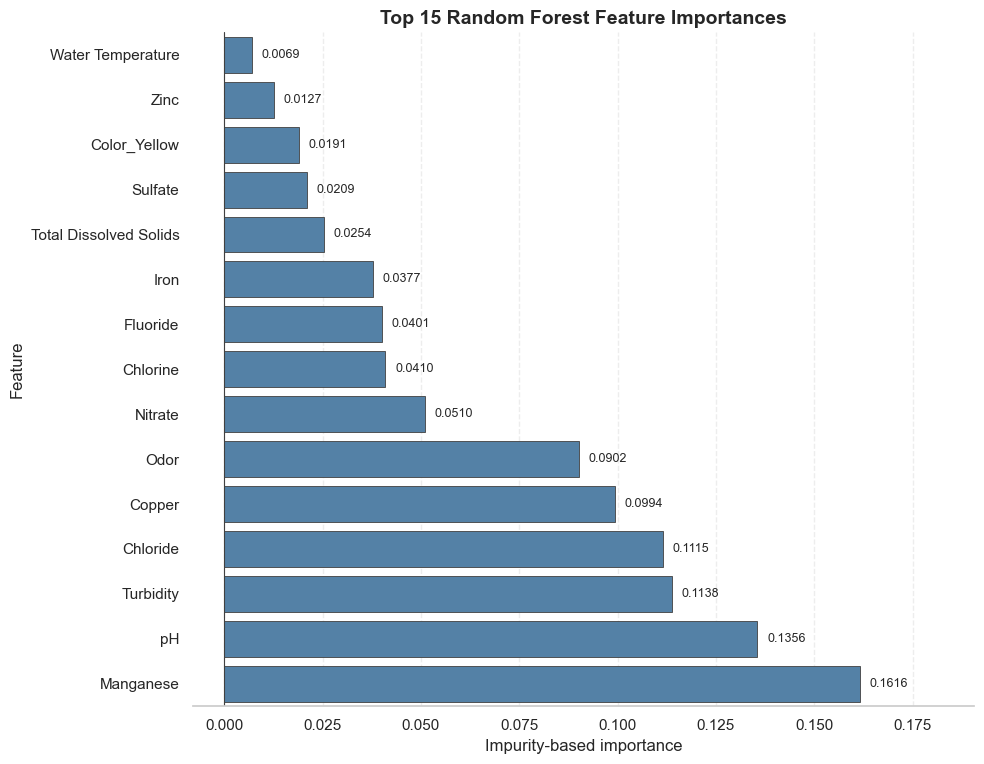

Saved figure to: E:\Python and Advanced Data Science\Project\reports\figures\ensemble_random_forest_cumulative_importance.png


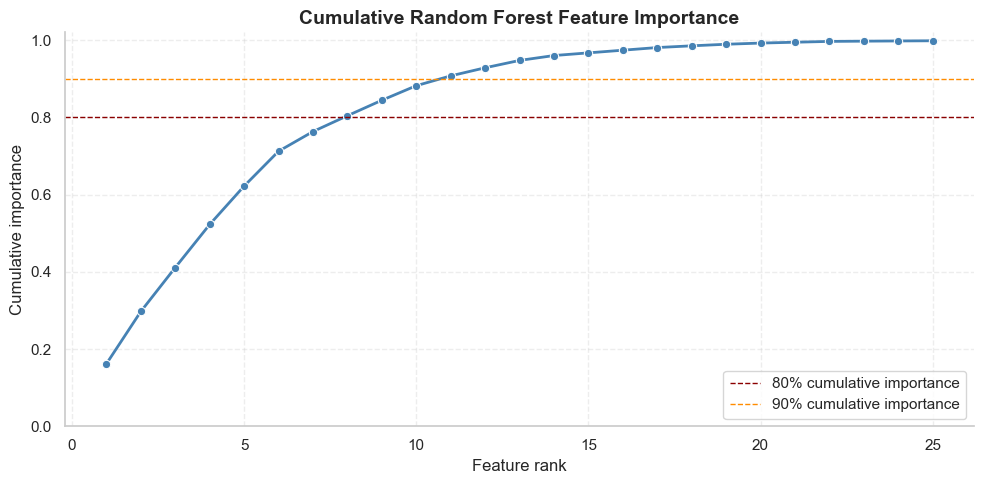

In [19]:
# Enhanced Random Forest impurity-based importance plot
rf_importance_enhanced = rf_importance.copy().reset_index(drop=True)

if 'rank' not in rf_importance_enhanced.columns:
    rf_importance_enhanced.insert(0, 'rank', np.arange(1, len(rf_importance_enhanced) + 1))

rf_importance_enhanced['importance_pct'] = (
    100 * rf_importance_enhanced['importance'] / rf_importance_enhanced['importance'].sum()
)
rf_importance_enhanced['cumulative_importance'] = rf_importance_enhanced['importance'].cumsum()

display(
    rf_importance_enhanced[
        ['rank', 'feature', 'importance', 'importance_pct', 'cumulative_importance']
    ].head(TOP_N_IMPORTANCE).round(4)
)

fig, ax = plot_ranked_bar(
    data=rf_importance_enhanced,
    value_col='importance',
    title=f'Top {TOP_N_IMPORTANCE} Random Forest Feature Importances',
    xlabel='Impurity-based importance',
    file_name='ensemble_random_forest_feature_importance_enhanced.png',
    color='steelblue',
    top_n=TOP_N_IMPORTANCE,
)
plt.show()

# Cumulative importance shows whether a few predictors dominate the model.
rf_cumulative = rf_importance_enhanced.head(TOP_N_CUMULATIVE).copy()
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=rf_cumulative,
    x='rank',
    y='cumulative_importance',
    marker='o',
    linewidth=2,
    color='steelblue',
    ax=ax,
)
ax.axhline(0.80, color='darkred', linestyle='--', linewidth=1, label='80% cumulative importance')
ax.axhline(0.90, color='darkorange', linestyle='--', linewidth=1, label='90% cumulative importance')
ax.set_title('Cumulative Random Forest Feature Importance', fontsize=14, weight='bold')
ax.set_xlabel('Feature rank')
ax.set_ylabel('Cumulative importance')
ax.set_ylim(0, 1.02)
ax.legend(loc='lower right')
ax.grid(axis='both', linestyle='--', alpha=0.35)
sns.despine(ax=ax)
plt.tight_layout()
save_report_figure(fig, 'ensemble_random_forest_cumulative_importance.png')
plt.show()


,model,feature,importance_mean,importance_std,rank,importance_low,importance_high
0,HistGradientBoosting,pH,0.1170,0.0007,1,0.1163,0.1177
1,HistGradientBoosting,Manganese,0.0923,0.0012,2,0.0911,0.0935
2,HistGradientBoosting,Turbidity,0.0792,0.0008,3,0.0784,0.0801
3,HistGradientBoosting,Chloride,0.0733,0.0008,4,0.0725,0.0740
4,HistGradientBoosting,Odor,0.0699,0.0007,5,0.0692,0.0707
5,HistGradientBoosting,Copper,0.0680,0.0015,6,0.0665,0.0695
6,HistGradientBoosting,Chlorine,0.0563,0.0009,7,0.0554,0.0572
7,HistGradientBoosting,Iron,0.0534,0.0007,8,0.0527,0.0541
8,HistGradientBoosting,Nitrate,0.0524,0.0008,9,0.0517,0.0532
9,HistGradientBoosting,Fluoride,0.0506,0.0010,10,0.0495,0.0516


Saved figure to: E:\Python and Advanced Data Science\Project\reports\figures\ensemble_histgradientboosting_permutation_importance_enhanced.png


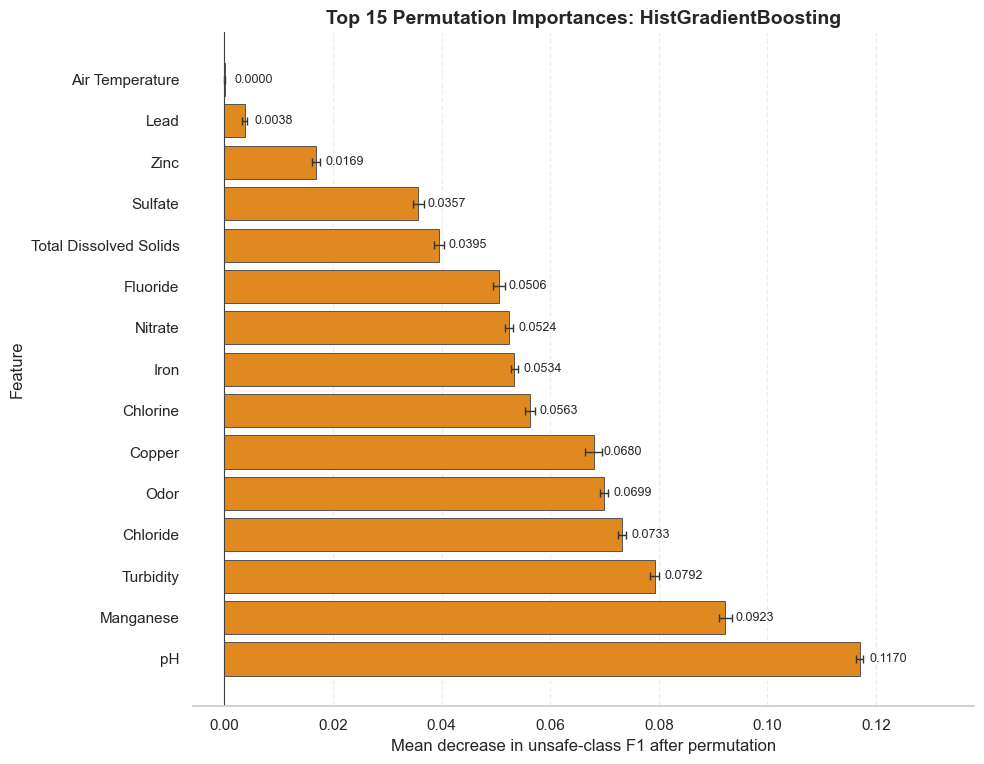

Saved figure to: E:\Python and Advanced Data Science\Project\reports\figures\ensemble_random_forest_permutation_importance_enhanced.png


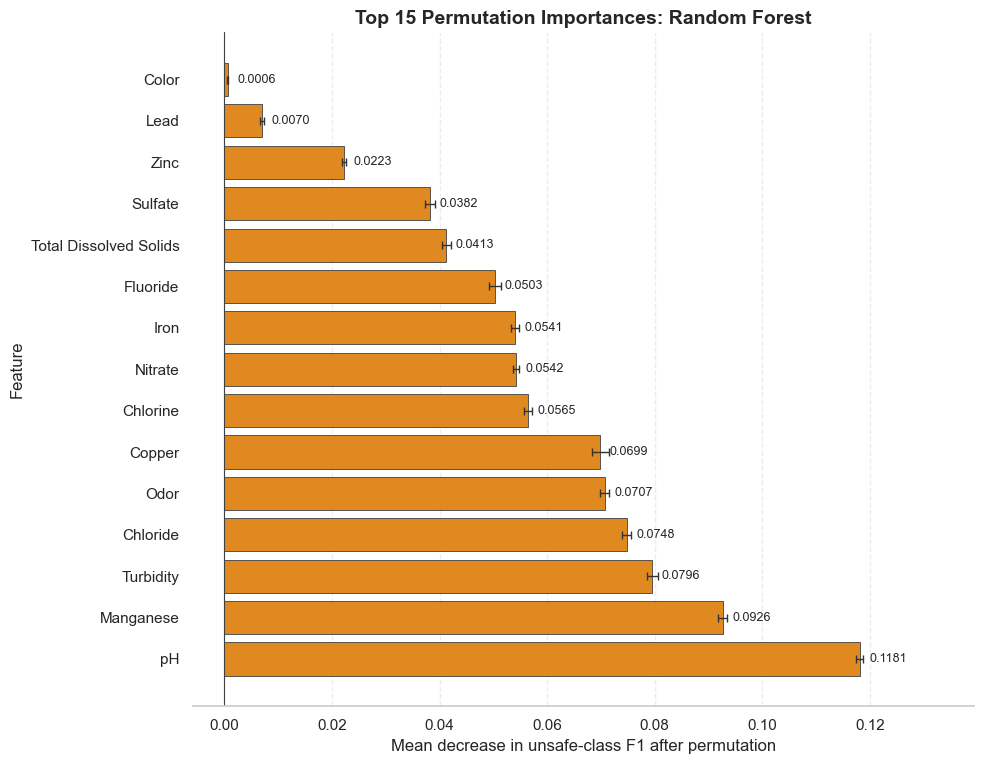

Saved figure to: E:\Python and Advanced Data Science\Project\reports\figures\ensemble_permutation_importance_heatmap.png


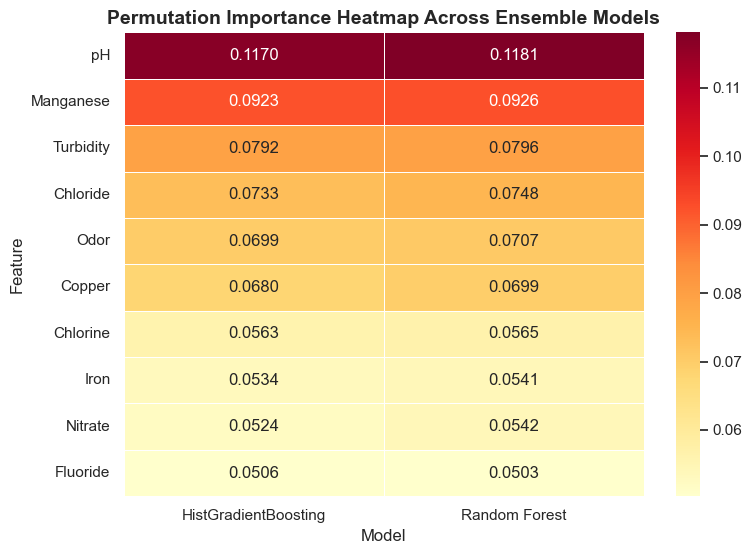

Saved figure to: E:\Python and Advanced Data Science\Project\reports\figures\ensemble_permutation_importance_model_comparison.png


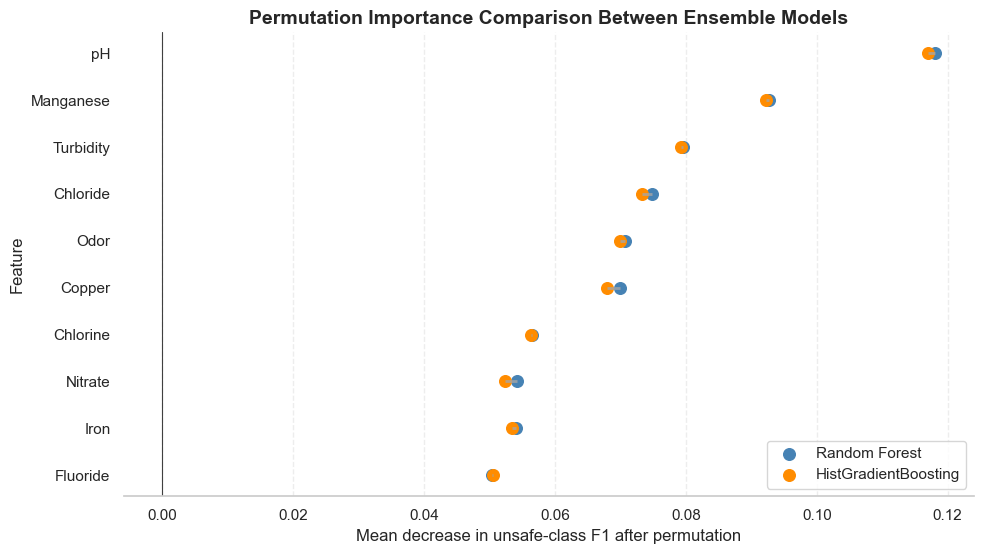

In [20]:
# Enhanced permutation-importance visualizations
permutation_importance_enhanced = permutation_importance_df.copy()
permutation_importance_enhanced = permutation_importance_enhanced.sort_values(
    ['model', 'importance_mean'], ascending=[True, False]
).reset_index(drop=True)
permutation_importance_enhanced['rank'] = (
    permutation_importance_enhanced.groupby('model').cumcount() + 1
)

if 'importance_low' not in permutation_importance_enhanced.columns:
    permutation_importance_enhanced['importance_low'] = (
        permutation_importance_enhanced['importance_mean']
        - permutation_importance_enhanced['importance_std']
    )
    permutation_importance_enhanced['importance_high'] = (
        permutation_importance_enhanced['importance_mean']
        + permutation_importance_enhanced['importance_std']
    )

display(permutation_importance_enhanced.groupby('model').head(TOP_N_PERMUTATION).round(4))

# 1. Separate bar charts with uncertainty bars for each ensemble model.
for model_name in permutation_importance_enhanced['model'].unique():
    model_table = permutation_importance_enhanced[
        permutation_importance_enhanced['model'] == model_name
    ]
    safe_name = safe_filename(model_name)

    fig, ax = plot_ranked_bar(
        data=model_table,
        value_col='importance_mean',
        err_col='importance_std',
        title=f'Top {TOP_N_PERMUTATION} Permutation Importances: {model_name}',
        xlabel='Mean decrease in unsafe-class F1 after permutation',
        file_name=f'ensemble_{safe_name}_permutation_importance_enhanced.png',
        color='darkorange',
        top_n=TOP_N_PERMUTATION,
    )
    plt.show()

# 2. Heatmap comparing the most important features across ensemble models.
top_features_for_heatmap = (
    permutation_importance_enhanced
    .groupby('model')
    .head(10)['feature']
    .drop_duplicates()
    .tolist()
)

heatmap_data = (
    permutation_importance_enhanced[
        permutation_importance_enhanced['feature'].isin(top_features_for_heatmap)
    ]
    .pivot(index='feature', columns='model', values='importance_mean')
    .fillna(0)
)
heatmap_data['average_importance'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('average_importance', ascending=False).drop(
    columns='average_importance'
)

fig, ax = plt.subplots(figsize=(8, max(5, 0.42 * len(heatmap_data) + 1.5)))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
)
ax.set_title('Permutation Importance Heatmap Across Ensemble Models', fontsize=14, weight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Feature')
plt.tight_layout()
save_report_figure(fig, 'ensemble_permutation_importance_heatmap.png')
plt.show()

# 3. Dumbbell plot: compare whether both ensemble models rely on the same predictors.
required_models = {'Random Forest', 'HistGradientBoosting'}

if required_models.issubset(heatmap_data.columns):
    comparison_plot_data = heatmap_data.copy()
    comparison_plot_data['max_importance'] = comparison_plot_data[list(required_models)].max(axis=1)
    comparison_plot_data = comparison_plot_data.sort_values('max_importance').tail(TOP_N_PERMUTATION)

    y_positions = np.arange(len(comparison_plot_data))
    fig, ax = plt.subplots(figsize=(10, max(5, 0.42 * len(comparison_plot_data) + 1.5)))

    ax.hlines(
        y=y_positions,
        xmin=comparison_plot_data['Random Forest'],
        xmax=comparison_plot_data['HistGradientBoosting'],
        color='0.65',
        linewidth=2,
        alpha=0.8,
    )
    ax.scatter(comparison_plot_data['Random Forest'], y_positions, color='steelblue', s=70, label='Random Forest')
    ax.scatter(comparison_plot_data['HistGradientBoosting'], y_positions, color='darkorange', s=70, label='HistGradientBoosting')

    ax.axvline(0, color='0.25', linewidth=0.8)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(comparison_plot_data.index)
    ax.set_title('Permutation Importance Comparison Between Ensemble Models', fontsize=14, weight='bold')
    ax.set_xlabel('Mean decrease in unsafe-class F1 after permutation')
    ax.set_ylabel('Feature')
    ax.legend(loc='lower right')
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.grid(axis='y', visible=False)
    sns.despine(ax=ax, left=True, bottom=False)
    plt.tight_layout()
    save_report_figure(fig, 'ensemble_permutation_importance_model_comparison.png')
    plt.show()


In [21]:
# Interpretation-ready summary table
importance_summary_rows = []

importance_summary_rows.append(
    {
        'view': 'Random Forest impurity importance',
        'model': 'Random Forest',
        'top_features': ', '.join(rf_importance_enhanced.head(10)['feature'].tolist()),
    }
)

for model_name in permutation_importance_enhanced['model'].unique():
    top_features = (
        permutation_importance_enhanced[
            permutation_importance_enhanced['model'] == model_name
        ]
        .head(10)['feature']
        .tolist()
    )
    importance_summary_rows.append(
        {
            'view': 'Permutation importance',
            'model': model_name,
            'top_features': ', '.join(top_features),
        }
    )

importance_summary_df = pd.DataFrame(importance_summary_rows)
importance_summary_path = RESULT_DIR / 'ensemble_feature_importance_summary.csv'
importance_summary_df.to_csv(importance_summary_path, index=False)

rf_top10 = set(rf_importance_enhanced.head(10)['feature'])
permutation_top10_union = set(
    permutation_importance_enhanced.groupby('model').head(10)['feature']
)
overlap_features = sorted(rf_top10.intersection(permutation_top10_union))

print(f'Saved feature-importance summary to: {importance_summary_path}')
print('\nFeatures appearing in both RF impurity top 10 and at least one permutation top 10:')
print(', '.join(overlap_features) if overlap_features else 'No overlap found.')
print('\nReminder: feature importance describes predictive relevance, not causal effect.')
print('Correlated water-quality variables may share, hide, or redistribute importance.')

display(importance_summary_df)


Saved feature-importance summary to: E:\Python and Advanced Data Science\Project\reports\model_results\ensemble_feature_importance_summary.csv

Features appearing in both RF impurity top 10 and at least one permutation top 10:
Chloride, Chlorine, Copper, Fluoride, Iron, Manganese, Nitrate, Odor, Turbidity, pH

Reminder: feature importance describes predictive relevance, not causal effect.
Correlated water-quality variables may share, hide, or redistribute importance.


,view,model,top_features
0,Random Forest impurity importance,Random Forest,"Manganese, pH, Turbidity, Chloride, Copper, Od..."
1,Permutation importance,HistGradientBoosting,"pH, Manganese, Turbidity, Chloride, Odor, Copp..."
2,Permutation importance,Random Forest,"pH, Manganese, Turbidity, Chloride, Odor, Copp..."


### Step 9: Final Model Selection and Conclusion

This final section converts the model-comparison results into a short conclusion, similar to the final-conclusion section in the Logistic Regression notebook. It identifies the best model under different criteria and gives report-ready interpretation guidance.


In [22]:
# Dynamic final model-selection summary
# The table selects the preferred model under different evaluation criteria.
final_candidate_results = all_ensemble_results.copy()

selection_rows = []
selection_criteria = {
    'best_f1_unsafe': 'f1_unsafe',
    'best_recall_unsafe': 'recall_unsafe',
    'best_pr_auc': 'pr_auc',
    'best_roc_auc': 'roc_auc',
}

for criterion_name, metric_name in selection_criteria.items():
    best_row = final_candidate_results.sort_values(metric_name, ascending=False).iloc[0]
    selection_rows.append(
        {
            'criterion': criterion_name,
            'metric': metric_name,
            'preferred_model': best_row['model'],
            'score': best_row[metric_name],
        }
    )

model_selection_summary = pd.DataFrame(selection_rows)
selection_summary_path = RESULT_DIR / 'ensemble_final_model_selection_summary.csv'
model_selection_summary.to_csv(selection_summary_path, index=False)

print(f'Saved final model-selection summary to: {selection_summary_path}')
display(model_selection_summary.round(4))

primary_recall_model = model_selection_summary.loc[
    model_selection_summary['criterion'] == 'best_recall_unsafe', 'preferred_model'
].iloc[0]
primary_f1_model = model_selection_summary.loc[
    model_selection_summary['criterion'] == 'best_f1_unsafe', 'preferred_model'
].iloc[0]
primary_pr_model = model_selection_summary.loc[
    model_selection_summary['criterion'] == 'best_pr_auc', 'preferred_model'
].iloc[0]

print('Suggested interpretation:')
print(f'- If the priority is minimizing missed unsafe samples, emphasize {primary_recall_model}.')
print(f'- If the priority is balanced unsafe-class performance, emphasize {primary_f1_model}.')
print(f'- If the priority is ranking/probability quality under class imbalance, emphasize {primary_pr_model}.')


# Also display the comparison against the teammate's Decision Tree baseline if available.
if 'comparison_with_decision_tree_baseline' in globals():
    baseline_candidate_results = comparison_with_decision_tree_baseline.copy()
    display(baseline_candidate_results.round(4))

    best_overall_f1 = baseline_candidate_results.sort_values('f1_unsafe', ascending=False).iloc[0]
    best_overall_recall = baseline_candidate_results.sort_values('recall_unsafe', ascending=False).iloc[0]

    print('\nBaseline comparison note:')
    print(
        f"- Best unsafe F1 among baseline and ensemble models: "
        f"{best_overall_f1['model']} ({best_overall_f1['f1_unsafe']:.4f})"
    )
    print(
        f"- Best unsafe recall among baseline and ensemble models: "
        f"{best_overall_recall['model']} ({best_overall_recall['recall_unsafe']:.4f})"
    )


Saved final model-selection summary to: E:\Python and Advanced Data Science\Project\reports\model_results\ensemble_final_model_selection_summary.csv


,criterion,metric,preferred_model,score
0,best_f1_unsafe,f1_unsafe,Random Forest (tuned),0.7794
1,best_recall_unsafe,recall_unsafe,Random Forest,0.9881
2,best_pr_auc,pr_auc,Random Forest (tuned),0.6826
3,best_roc_auc,roc_auc,Random Forest (tuned),0.9226


Suggested interpretation:
- If the priority is minimizing missed unsafe samples, emphasize Random Forest.
- If the priority is balanced unsafe-class performance, emphasize Random Forest (tuned).
- If the priority is ranking/probability quality under class imbalance, emphasize Random Forest (tuned).


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
2,HistGradientBoosting,0.8711,0.6467,0.9702,0.7761,0.9176,0.6478
1,Random Forest,0.8669,0.6357,0.9881,0.7736,0.9204,0.6642
0,Decision Tree (04 tuned baseline),0.8591,0.6485,0.8472,0.7346,0.9130,0.6462



Baseline comparison note:
- Best unsafe F1 among baseline and ensemble models: HistGradientBoosting (0.7761)
- Best unsafe recall among baseline and ensemble models: Random Forest (0.9881)


### Conclusion

Compared with the tuned Decision Tree baseline from `04_model_2.ipynb`, the ensemble models provide a stronger or more stable non-linear modeling approach because they aggregate multiple trees or boosting steps instead of relying on a single tree structure. This is appropriate for the dataset because many water-quality indicators may affect safety in non-linear ways.

For this project, the preferred ensemble model should be selected based on the unsafe class rather than accuracy alone. If public-health risk is the main concern, **unsafe recall** is especially important because false negatives mean unsafe water is incorrectly classified as safe. If balanced classification quality is preferred, **unsafe F1-score** should be emphasized. Because the dataset is class-imbalanced, **PR-AUC** is also more informative than accuracy alone.

Feature-importance results should be interpreted as predictive evidence, not causal evidence. Variables such as conductivity, total dissolved solids, chloride, and sulfate may be correlated, and correlated predictors can share or hide importance. Therefore, Random Forest importance, permutation importance, and domain knowledge should be discussed together.

---

与 `04_model_2.ipynb` 中调参后的 Decision Tree baseline 相比，集成模型通过多棵树或逐步 boosting 的方式建模，通常可以提供更稳定的非线性预测能力。由于很多水质指标对安全性的影响可能不是简单线性的，因此 Random Forest 和 HistGradientBoosting 这类模型适合作为更复杂的建模方法。

最终报告中不要只看 accuracy，而应重点关注 unsafe 类的 recall、F1 和 PR-AUC。如果研究重点是尽量不要漏判不安全水样，应优先解释 unsafe recall 最高的模型。如果研究重点是综合平衡，则可以强调 unsafe F1 最高的模型。

变量重要性只能说明预测相关性，不能直接说明因果关系。由于部分水质变量在物理化学上可能相关，例如 Conductivity、TDS、Chloride 和 Sulfate，因此需要结合 permutation importance 和 domain knowledge 谨慎解释。
